# Perfect Foresight CRRA Model - Approximation


In [1]:
# Initial notebook set up
from HARK.ConsumptionSaving.ConsIndShockModel import (
    PerfForesightConsumerType,
    init_perfect_foresight,
)  # Import the consumer type
import matplotlib.pyplot as plt

import numpy as np
from copy import deepcopy


def mystr(number):
    return "{:.4f}".format(number)


# These last two will make our charts look nice
plt.style.use("seaborn-v0_8-darkgrid")
palette = plt.get_cmap("Dark2")

[PerfectForesightCRRA](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra) derives a number of results as approximations; for instance, the exact formula for the consumption function is derived as $$c_t = \left(\frac{R - (R\beta)^{1/\rho}}{R}\right)o_t$$
and approximated by $$c_t \approx (r-\rho^{-1}(r-\theta))o_t$$.

Your task is to make a series of plots that show how the quality of the approximation deteriorates as you change various model parameters. The notebook aims to make this easier by showing that under the baseline parameter values, the percentage amount of the error is pretty much constant across different values of market resources, so you can assume that is generically true.

To get you started, we show how to conduct the exercise under particularly simple parameterization (the Deaton/Friedman model where $R = \frac{1}{\beta}$, in which the only relevant parameter is the interest rate).

Your specific assignment is:

1. Starting with the default parameterization of the model, show how the approximation quality changes with values of other parameters
1. Explain, mathematically, why you get the patterns you do for how the solutions deteriorate as you change the parameter values

Hints:

1. [MathFactsList](https://intertemporal-choice.github.io/content/numerical/mathfactslist) describes the conditions under which the approximations will be good; you want to find conditions under which the approximations get bad
2. An interesting question is the extent to which the size of approximation errors is related to the degree of impatience according to alternative metrics

In [2]:
# Set up a HARK Perfect Foresight Consumer called PFagent


# Now we need to give our consumer parameter values that allow us to solve the consumer's problem

# Invoke it to create a dictionary called Paramod (Params that we will modify)
# deepcopy prevents later overwriting
Paramod = deepcopy(init_perfect_foresight)

# Extract the parameters from the dictionary to make them easy to reference
CRRA = Paramod["CRRA"]  # Coefficient of relative risk aversion
Rfree = Paramod["Rfree"][0]  # Interest factor on assets
DiscFac = Paramod["DiscFac"]  # Intertemporal discount factor
PermGroFac = Paramod["PermGroFac"]  # Permanent income growth factor
LivPrb = Paramod["LivPrb"] = [1.0]  # Survival probability of 100 percent
# This says that it is an infinite horizon model
cycles = Paramod["cycles"] = 0

In [3]:
# Now let's pass our dictionary to our consumer class to create an instance
PFagent = PerfForesightConsumerType(
    **Paramod
)  # Any parameters we did not modify get their default values

# Solve the agent's problem
PFagent.solve()

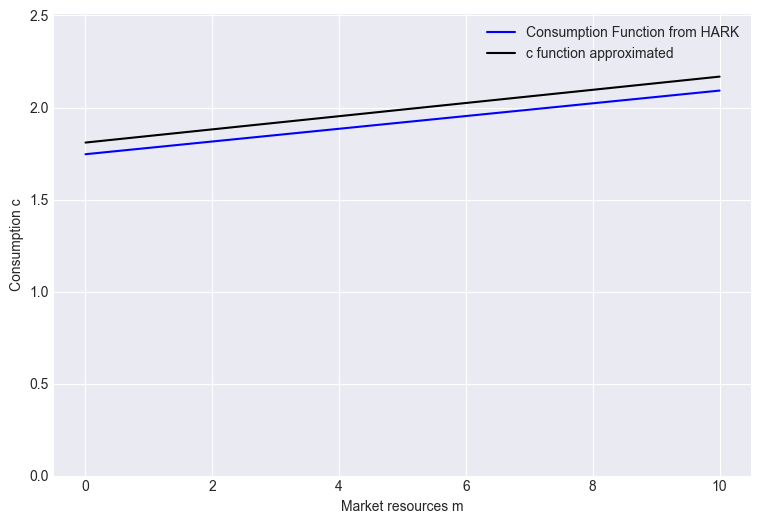

In [4]:
# Plot the consumption function approximation versus the "true" consumption function

# Set out some range of market resources that we want to plot consumption for
mMin = 0
mMax = 10
numPoints = 100
m_range = np.linspace(
    mMin, mMax, numPoints
)  # This creates an array of points in the given range

wealthHmn = PFagent.solution[
    0
].hNrm  # normalized human wealth is constructed when we .solve()
wealthMkt = m_range  # bank balances plus current income
wealthTot = wealthHmn + wealthMkt  # Total wealth is the sum of human and market

# Feed our range of market resources into our consumption function in order to get consumption at each point
# (Remember, after doing .solve(), the consumption function is stored as PFagent.solution[0].cFunc)
cHARK = PFagent.solution[0].cFunc(
    m_range
)  # Because the input m_range is an array, the output cHARK is too
cMax = (
    cHARK[-1] * 1.2
)  # The last point will be the largest; add 20 percent for visual appeal

# Use matplotlib package (imported in first cell) to plot the consumption function
plt.figure(figsize=(9, 6))  # set the figure size
plt.plot(
    m_range, cHARK, "b", label="Consumption Function from HARK"
)  # m on the x axis vs c on the y axis
# 'b' is for blue
plt.xlabel("Market resources m")  # x axis label
plt.ylabel("Consumption c")  # y axis label
plt.ylim(0, cMax)

# The plot is named plt and it hangs around like a variable
# but is not displayed until you do a plt.show()

# Construct the approximate consumption function
# Also, recall that in the "true" consumption function what matters is total wealth,
# not just market resources so we need to add in human wealth

# Use the values of R, beta, and rho that we used above to construct rates
rfree = Rfree - 1
discRte = (
    1 / DiscFac
) - 1  # See handout for why this is approximately the time preference rate
cApprox = wealthTot * (rfree - (1 / CRRA) * (rfree - discRte))
plt.plot(
    m_range, cApprox, "k", label="c function approximated"
)  # Add approximate consumption function line
plt.legend()  # show the legend

plt.show()  # show the plot

The size of the error looks pretty stable, which we can show by calculating it in percentage terms

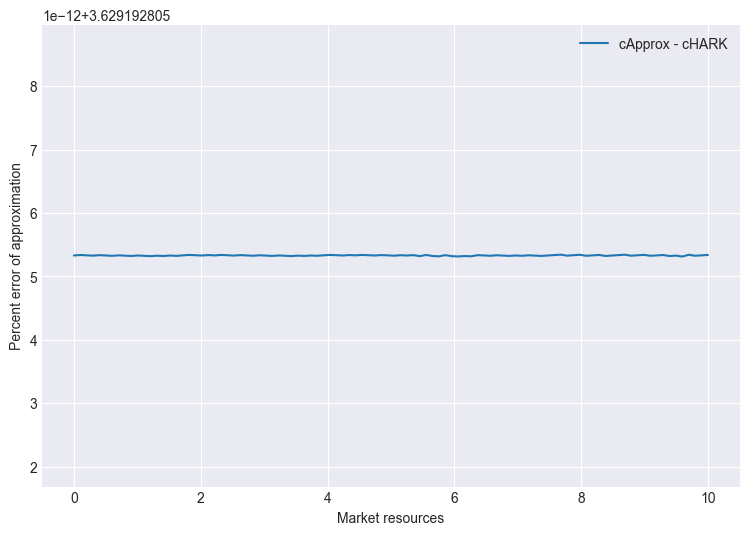

In [5]:
# Plot the deviations
approximationError = 100 * (cApprox - cHARK) / cHARK
plt.figure(figsize=(9, 6))  # set the figure size
plt.plot(m_range, approximationError, label="cApprox - cHARK")
plt.xlabel("Market resources")  # x axis label
plt.ylabel("Percent error of approximation")  # y axis label
plt.legend()
plt.show()

Now we want to calculate how the approximation quality depends on the interest factor.  We proceed as follows:
1. Create an array of $R$ values, and the array of $\beta = 1/R$ that goes with it, so that $R \beta = 1$ at every $R$.  The return patience factor then falls as $R$ rises through the array
2. Set up a for loop in which we will:
    1. Input the new values of $R$ and $\beta$
    0. Solve the HARK model for the consumption function
    0. Calculate the approximate consumption function, using the same $R$ and $\beta$
    0. Save the percentage error of the approximation, which is the same at every value of market resources
3. Then we can plot the percentage error against the $R$ factor

When you vary the parameters yourself, set `PFagent.tolerance = 1e-12`, as the loop below does.  HARK solves the infinite horizon problem by iterating until successive solutions differ by less than `tolerance`, whose default of `1e-6` can stop it well short of the exact solution.  When the return patience factor $\textbf{Þ}_R = (R\beta)^{1/\rho}/R$ or the finite human wealth factor $G/R$ is close to 1, even that is not enough, because HARK stops after 5000 iterations whatever the tolerance; there, check HARK's solution against the exact formula above.  The [return impatience condition](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra#eq-patr) (RIC) and the [finite human wealth condition](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra#eq-fhwcpf) (FHWC) require each factor to be below 1.

In [6]:
# Create array of Rfree values, and calculate the patience factor
howMany = 30
Rfree_min = Rfree
Rfree_max = Rfree**20
Rfree_array = np.linspace(Rfree_min, Rfree_max, howMany)

# Set the time preference factor to match the interest factor, so that R * beta = 1 at every R
DiscFac_array = 1 / Rfree_array

Pat_array = (Rfree_array * DiscFac_array) ** (1 / CRRA)
PatR_array = Pat_array / Rfree_array

In [7]:
# Start the consumer at the first pair of R and beta; the loop below resets both at each R

Paramod["DiscFac"] = DiscFac_array[0]

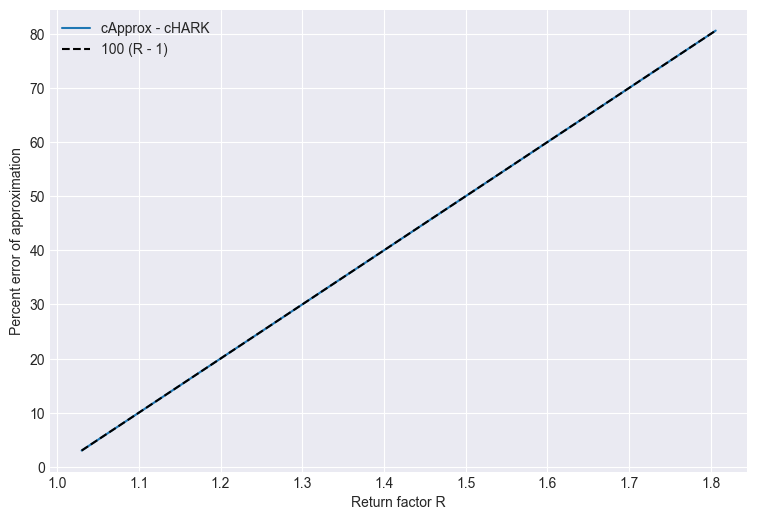

In [8]:
# Plot the percentage error of the approximation against the return factor
PFagent = PerfForesightConsumerType(
    **Paramod
)  # construct a consumer with our previous parameters
PFagent.tolerance = 1e-12  # solve more precisely than the default of 1e-6

plt.figure(figsize=(9, 6))  # set the figure size
pct_error = np.zeros(howMany)

for i in range(len(Rfree_array)):
    PFagent.Rfree = [Rfree_array[i]]
    PFagent.DiscFac = DiscFac_array[i]

    # Now we just copy the lines of code from above that we want
    PFagent.solve()
    cHARK = PFagent.solution[0].cFunc(m_range)
    wealthHmn = PFagent.solution[0].hNrm
    wealthTot = wealthHmn + m_range
    rfree = Rfree_array[i] - 1
    discRte = (1 / DiscFac_array[i]) - 1
    cApprox = wealthTot * (rfree - (1 / CRRA) * (rfree - discRte))
    # The percentage error is the same at every m, so its mean is that one number
    pct_error[i] = np.mean(100 * (cApprox - cHARK) / cHARK)

plt.plot(Rfree_array, pct_error, label="cApprox - cHARK")
plt.plot(Rfree_array, 100 * (Rfree_array - 1), "k--", label="100 (R - 1)")
plt.xlabel("Return factor R")  # x axis label
plt.ylabel("Percent error of approximation")  # y axis label
plt.legend()
plt.show()

With $R \beta = 1$ at every $R$, the approximation overstates consumption by a proportion exactly equal to the interest rate $r = R - 1$: by 3 percent at the baseline $R = 1.03$, rising to about 81 percent at $R = 1.81$, the top of the grid.  The approximation is exact only in the limit as $R$ approaches 1.